# 04 - Reprodução dos principais resultados do artigo

Este notebook transcreve dados das Tabelas 1, 2, 4, 5 e 6 de Ravi et
al. (2024), recalcula os ganhos destacados no texto e gera figuras.

**Natureza da reprodução:** os números são os valores publicados, não
uma nova execução dos benchmarks. Uma execução integral exigiria os
datasets, protocolos oficiais e a infraestrutura do paper.

In [1]:
from pathlib import Path


def locate_seminar_dir():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        seminar = candidate if candidate.name == "seminar_2" else candidate / "seminar_2"
        if (seminar / "articles").is_dir():
            return seminar
    raise FileNotFoundError("Execute este notebook dentro do repositório TP558.")


SEMINAR_DIR = locate_seminar_dir()
DATA_DIR = SEMINAR_DIR / "data"
OUTPUT_DIR = DATA_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(SEMINAR_DIR)

/home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/seminar_2


In [2]:
import csv

import matplotlib.pyplot as plt
import numpy as np

TABLE_DIR = DATA_DIR / "processed" / "paper_results"
TABLE_DIR.mkdir(parents=True, exist_ok=True)


def save_table(filename, header, rows):
    with (TABLE_DIR / filename).open("w", newline="", encoding="utf-8") as stream:
        writer = csv.writer(stream)
        writer.writerow(header)
        writer.writerows(rows)

## Tabela 1 - eficiência do data engine

A Fase 1 usa SAM e edição manual em todos os frames. Nas Fases 2 e 3,
SAM 2 propaga máscaras e o anotador corrige apenas falhas. O quociente
$37{,}8/4{,}5=8{,}4$ reproduz o ganho citado no texto.

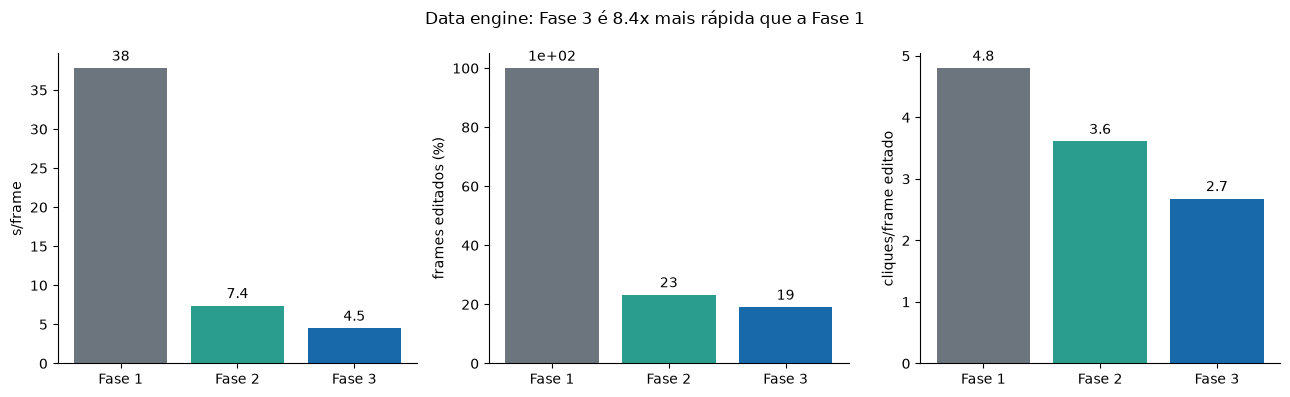

In [3]:
phases = ["Fase 1", "Fase 2", "Fase 3"]
time_per_frame = np.array([37.8, 7.4, 4.5])
edited_frames = np.array([100.0, 23.25, 19.04])
clicks = np.array([4.80, 3.61, 2.68])
speedup = time_per_frame[0] / time_per_frame[-1]
assert np.isclose(speedup, 8.4)

save_table(
    "table_1_data_engine.csv",
    ["phase", "seconds_per_frame", "edited_frames_pct", "clicks_per_clicked_frame"],
    zip(phases, time_per_frame, edited_frames, clicks, strict=True),
)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
series = [(time_per_frame, "s/frame"), (edited_frames, "frames editados (%)"), (clicks, "cliques/frame editado")]
for ax, (values, label) in zip(axes, series, strict=True):
    bars = ax.bar(phases, values, color=["#6c757d", "#2a9d8f", "#1769aa"])
    ax.bar_label(bars, fmt="%.2g", padding=3)
    ax.set_ylabel(label)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle(f"Data engine: Fase 3 é {speedup:.1f}x mais rápida que a Fase 1")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "paper_data_engine.png", dpi=180, bbox_inches="tight")
plt.show()

## Tabela 2 - efeito das fases de coleta

Mantendo o número de iterações fixo, adicionar dados de cada fase
melhora $J\&F$ em SA-V e nos nove benchmarks zero-shot. O crescimento
em SA-V é maior porque o domínio é diretamente beneficiado pelo novo
conjunto de vídeos.

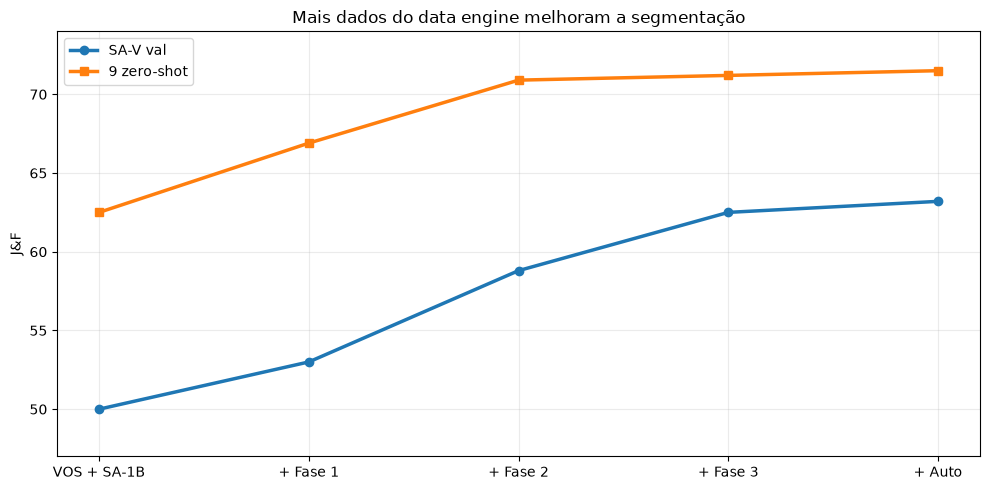

In [4]:
training_stages = ["VOS + SA-1B", "+ Fase 1", "+ Fase 2", "+ Fase 3", "+ Auto"]
sav_val = np.array([50.0, 53.0, 58.8, 62.5, 63.2])
zero_shot = np.array([62.5, 66.9, 70.9, 71.2, 71.5])
assert np.all(np.diff(sav_val) > 0) and np.all(np.diff(zero_shot) > 0)

save_table(
    "table_2_training_phases.csv",
    ["training_data", "sa_v_val_j_and_f", "nine_zero_shot_j_and_f"],
    zip(training_stages, sav_val, zero_shot, strict=True),
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(training_stages, sav_val, marker="o", linewidth=2.5, label="SA-V val")
ax.plot(training_stages, zero_shot, marker="s", linewidth=2.5, label="9 zero-shot")
ax.set(ylabel="J&F", ylim=(47, 74), title="Mais dados do data engine melhoram a segmentação")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "paper_training_phases.png", dpi=180, bbox_inches="tight")
plt.show()

## Tabela 4 - prompts no primeiro frame

A comparação agrega 17 datasets de vídeo. SAM 2 supera os pipelines
SAM+XMem++ e SAM+Cutie em cliques, caixa e máscara de referência.

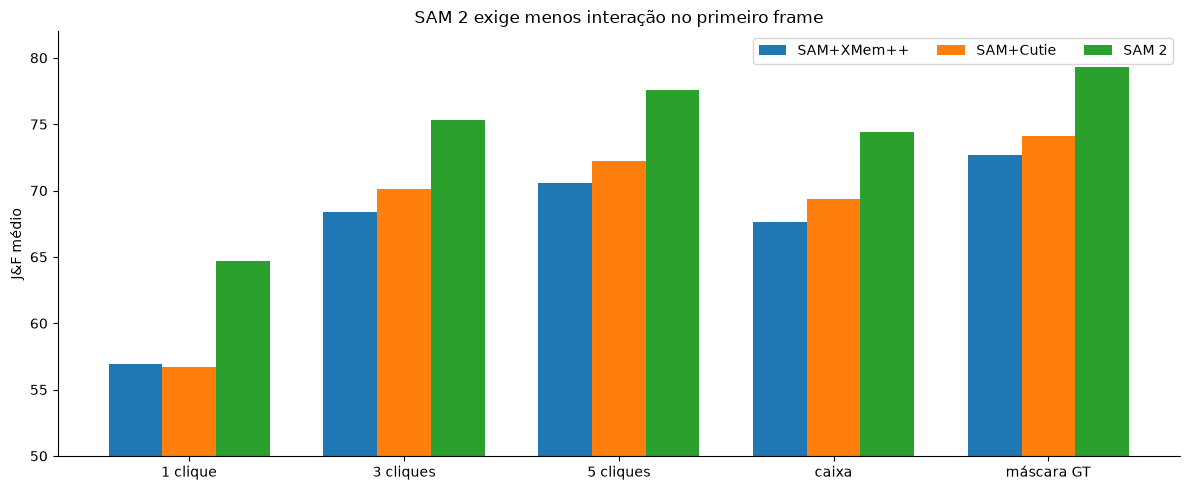

In [5]:
prompt_names = ["1 clique", "3 cliques", "5 cliques", "caixa", "máscara GT"]
prompt_results = {
    "SAM+XMem++": [56.9, 68.4, 70.6, 67.6, 72.7],
    "SAM+Cutie": [56.7, 70.1, 72.2, 69.4, 74.1],
    "SAM 2": [64.7, 75.3, 77.6, 74.4, 79.3],
}
assert all(np.all(np.array(prompt_results["SAM 2"]) > values) for name, values in prompt_results.items() if name != "SAM 2")

save_table(
    "table_4_prompt_types.csv",
    ["method", *prompt_names],
    ((method, *values) for method, values in prompt_results.items()),
)

x = np.arange(len(prompt_names))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 5))
for offset, (method, values) in enumerate(prompt_results.items()):
    ax.bar(x + (offset - 1) * width, values, width, label=method)
ax.set_xticks(x, prompt_names)
ax.set(ylabel="J&F médio", ylim=(50, 82), title="SAM 2 exige menos interação no primeiro frame")
ax.legend(ncols=3)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "paper_prompt_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

## Tabela 5 - imagem zero-shot e velocidade

Com os mesmos dados SA-1B, SAM 2 melhora levemente a mIoU de um clique
e publica cerca de seis vezes mais FPS. O treinamento misto aumenta a
acurácia, sobretudo nos 14 novos datasets de vídeo avaliados como
imagens. FPS foi medido em uma única GPU A100 e não deve ser comparado
diretamente ao tempo deste notebook.

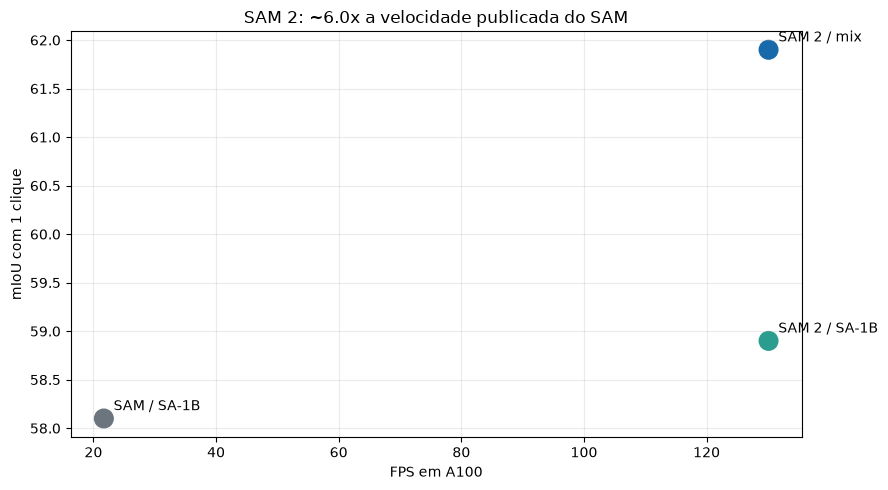

In [6]:
image_models = ["SAM / SA-1B", "SAM 2 / SA-1B", "SAM 2 / mix"]
miou_1_click = np.array([58.1, 58.9, 61.9])
miou_5_click = np.array([81.3, 81.7, 83.5])
fps = np.array([21.7, 130.1, 130.1])
fps_gain = fps[1] / fps[0]
assert np.isclose(fps_gain, 6.0, atol=0.02)

save_table(
    "table_5_image_segmentation.csv",
    ["model", "one_click_miou", "five_click_miou", "fps_a100"],
    zip(image_models, miou_1_click, miou_5_click, fps, strict=True),
)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#6c757d", "#2a9d8f", "#1769aa"]
ax.scatter(fps, miou_1_click, s=180, c=colors)
for x_value, y_value, label in zip(fps, miou_1_click, image_models, strict=True):
    ax.annotate(label, (x_value, y_value), xytext=(7, 6), textcoords="offset points")
ax.set(xlabel="FPS em A100", ylabel="mIoU com 1 clique", title=f"SAM 2: ~{fps_gain:.1f}x a velocidade publicada do SAM")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "paper_image_speed_accuracy.png", dpi=180, bbox_inches="tight")
plt.show()

## Tabela 6 - segmentação semi-supervisionada de vídeo

A entrada é a máscara verdadeira no primeiro frame. A figura resume o
melhor baseline completo da tabela (Cutie-base+) e as duas variantes
SAM 2. O paper usa $G$ no YouTube-VOS e $J\&F$ nos demais datasets.

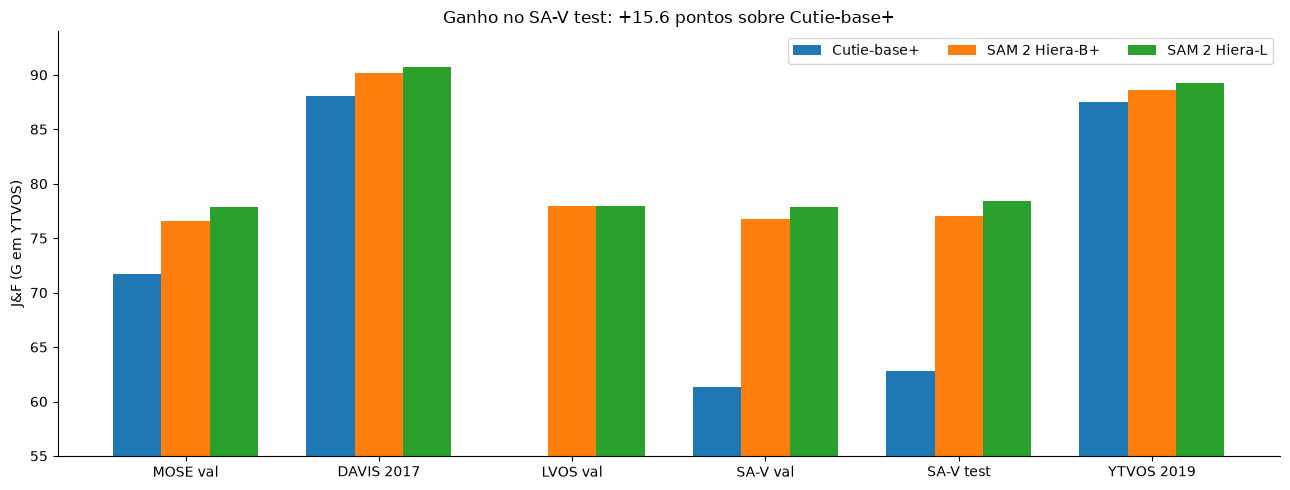

In [7]:
vos_datasets = ["MOSE val", "DAVIS 2017", "LVOS val", "SA-V val", "SA-V test", "YTVOS 2019"]
vos_results = {
    "Cutie-base+": [71.7, 88.1, np.nan, 61.3, 62.8, 87.5],
    "SAM 2 Hiera-B+": [76.6, 90.2, 78.0, 76.8, 77.0, 88.6],
    "SAM 2 Hiera-L": [77.9, 90.7, 78.0, 77.9, 78.4, 89.3],
}
gain_sav_test = vos_results["SAM 2 Hiera-L"][4] - vos_results["Cutie-base+"][4]
assert np.isclose(gain_sav_test, 15.6)

save_table(
    "table_6_vos.csv",
    ["method", *vos_datasets],
    ((method, *values) for method, values in vos_results.items()),
)

x = np.arange(len(vos_datasets))
width = 0.25
fig, ax = plt.subplots(figsize=(13, 5))
for offset, (method, values) in enumerate(vos_results.items()):
    ax.bar(x + (offset - 1) * width, values, width, label=method)
ax.set_xticks(x, vos_datasets)
ax.set(ylabel="J&F (G em YTVOS)", ylim=(55, 94), title=f"Ganho no SA-V test: +{gain_sav_test:.1f} pontos sobre Cutie-base+")
ax.legend(ncols=3)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "paper_vos_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

## Síntese

Os resultados sustentam três argumentos para o seminário: memória e
prompts corretivos reduzem interação; o data engine melhora eficiência
e qualidade; e o encoder Hiera entrega um compromisso forte entre
velocidade e acurácia. As tabelas processadas foram salvas em
`data/processed/paper_results/` para auditoria e reutilização.